In [2]:
from pathlib import Path

DATA_PATH = Path("project")
OUTPUT_PATH = Path("output")

OUTPUT_PATH.mkdir(exist_ok=True)

print("Data folder found:", DATA_PATH.exists())
print("Output folder found:", OUTPUT_PATH.exists())

Data folder found: True
Output folder found: True


In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [4]:
csv_files = sorted(DATA_PATH.glob("*.csv"))

print("Number of CSV files:", len(csv_files))

for file in csv_files:
    print("-", file.name)

Number of CSV files: 2
- tmdb_5000_credits.csv
- tmdb_5000_movies.csv


['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']


In [5]:
movies = pd.read_csv(DATA_PATH/"tmdb_5000_movies.csv")
credits = pd.read_csv(DATA_PATH/"tmdb_5000_credits.csv")

In [6]:
datasets = {
    "movies": movies,
    "credits": credits
}

list(datasets)

['movies', 'credits']

In [7]:
shape_summary = pd.DataFrame(
    [
        [name, data.shape[0], data.shape[1]]
        for name, data in datasets.items()
    ],
    columns=["dataset", "rows", "columns"]
)

shape_summary

,dataset,rows,columns
0,movies,4803,20
1,credits,4803,4


In [8]:
display(movies.head(3))
display(credits.head(3))

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.44,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.20,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.08,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.90,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.38,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.00,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.30,4466


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


In [9]:
print("Movie columns:")
print(movies.columns.tolist())

print("\nCredits columns:")
print(credits.columns.tolist())

Movie columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Credits columns:
['movie_id', 'title', 'cast', 'crew']


In [10]:
display(movies.dtypes.to_frame("movies_dtype"))
display(credits.dtypes.to_frame("credits_dtype"))

,movies_dtype
budget,int64
genres,object
homepage,object
id,int64
keywords,object
original_language,object
original_title,object
overview,object
popularity,float64
production_companies,object


,credits_dtype
movie_id,int64
title,object
cast,object
crew,object


In [11]:
print("Unique movie IDs in movies:", movies["id"].nunique())
print("Unique movie IDs in credits:", credits["movie_id"].nunique())

print("Duplicate movie IDs in movies:", movies["id"].duplicated().sum())
print("Duplicate movie IDs in credits:", credits["movie_id"].duplicated().sum())

Unique movie IDs in movies: 4803
Unique movie IDs in credits: 4803
Duplicate movie IDs in movies: 0
Duplicate movie IDs in credits: 0


### Checking data quality 
We will check:
- missing values,
- duplicate keys,
- invalid numeric values,
- invalid dates,
- and whether the two tables can be matched through their IDs.

In [12]:
quality_rows = []

for name, data in datasets.items():
    quality_rows.append({
        "dataset": name,
        "rows": len(data),
        "columns": data.shape[1],
        "missing_cells": int(data.isna().sum().sum()),#first sum is for calculating missing cells in each row and second sum is for calculating total missing values in entire dataset
        "duplicate_rows": int(data.duplicated().sum())
    })

quality_report = pd.DataFrame(quality_rows)
quality_report

,dataset,rows,columns,missing_cells,duplicate_rows
0,movies,4803,20,3941,0
1,credits,4803,4,0,0


In [13]:
movie_missing = (
    movies.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

movie_missing["missing_percent"] = (
    movie_missing["missing_count"] / len(movies) * 100
)

movie_missing.head(15)

,missing_count,missing_percent
homepage,3091,64.36
tagline,844,17.57
overview,3,0.06
runtime,2,0.04
release_date,1,0.02
id,0,0.00
budget,0,0.00
genres,0,0.00
original_title,0,0.00
popularity,0,0.00


In [14]:
credits_missing = (
    credits.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

credits_missing["missing_percent"] = (
    credits_missing["missing_count"] / len(credits) * 100
)

credits_missing.head(15)

,missing_count,missing_percent
movie_id,0,0.00
title,0,0.00
cast,0,0.00
crew,0,0.00


In [15]:
negative_values = pd.Series({
    "budget_negative": (movies["budget"] < 0).sum(),
    "revenue_negative": (movies["revenue"] < 0).sum(),
    "runtime_negative": (movies["runtime"] < 0).sum()
})

negative_values.to_frame("negative_rows")

,negative_rows
budget_negative,0
revenue_negative,0
runtime_negative,0


In [16]:
release_dates_test = pd.to_datetime(
    movies["release_date"],
    errors="coerce"
)

print("Invalid or missing release dates:", release_dates_test.isna().sum())
print("Minimum valid release date:", release_dates_test.min())
print("Maximum valid release date:", release_dates_test.max())

Invalid or missing release dates: 1
Minimum valid release date: 1916-09-04 00:00:00
Maximum valid release date: 2017-02-03 00:00:00


In [17]:
movie_ids = set(movies["id"])
credit_ids = set(credits["movie_id"])

print("Movie IDs without credits:", len(movie_ids - credit_ids))
print("Credit IDs without movie record:", len(credit_ids - movie_ids))

Movie IDs without credits: 0
Credit IDs without movie record: 0


### Cleaning and Preprocessing the data

In [18]:
movies_clean = movies.copy()
credits_clean = credits.copy()

In [19]:
movies_clean.dtypes

budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object

In [20]:
movies_clean["release_date"] = pd.to_datetime(
    movies_clean["release_date"],
    errors="coerce"
)
movies_clean["release_year"] = movies_clean["release_date"].dt.year.astype("Int64")

In [21]:
movies_clean["release_year"].head()

0    2009
1    2007
2    2015
3    2012
4    2012
Name: release_year, dtype: Int64

In [22]:
movies_clean.dtypes

budget                           int64
genres                          object
homepage                        object
id                               int64
keywords                        object
original_language               object
original_title                  object
overview                        object
popularity                     float64
production_companies            object
production_countries            object
release_date            datetime64[ns]
revenue                          int64
runtime                        float64
spoken_languages                object
status                          object
tagline                         object
title                           object
vote_average                   float64
vote_count                       int64
release_year                     Int64
dtype: object

In [23]:
movies_clean.shape

(4803, 21)

In [24]:
movies_clean.head(3)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,release_year
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.44,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.20,11800,2009
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.08,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.90,4500,2007
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.38,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.00,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.30,4466,2015


In [25]:
movie_columns = [
    "id",
    "title",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "vote_count",
    "release_date",
    "release_year",
    "runtime",
    "genres",
    "original_language",
    "status"
]
movies_selected = movies_clean[movie_columns].copy()
movies_selected.head()

,id,title,budget,revenue,popularity,vote_average,vote_count,release_date,release_year,runtime,genres,original_language,status
0,19995,Avatar,237000000,2787965087,150.44,7.20,11800,2009-12-10,2009,162.00,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Released
1,285,Pirates of the Caribbean: At World's End,300000000,961000000,139.08,6.90,4500,2007-05-19,2007,169.00,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,Released
2,206647,Spectre,245000000,880674609,107.38,6.30,4466,2015-10-26,2015,148.00,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Released
3,49026,The Dark Knight Rises,250000000,1084939099,112.31,7.60,9106,2012-07-16,2012,165.00,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,Released
4,49529,John Carter,260000000,284139100,43.93,6.10,2124,2012-03-07,2012,132.00,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Released


In [26]:
cleaning_summary = pd.DataFrame({
    "before": [movies_clean.shape[1]],
    "after": [movies_selected.shape[1]]
}, index=["columns"])

cleaning_summary["removed"] = (
    cleaning_summary["before"] - cleaning_summary["after"]
)

cleaning_summary

,before,after,removed
columns,21,13,8


In [27]:
credits.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


### Transforming the data

Creating financial features

ROI is calculated only for movies with a positive budget.

ROI = (Revenue - Budget) / Budget

This allows movies with different budget sizes to be compared.

In [28]:
movies_selected["profit"] = (
    movies_selected["revenue"] - movies_selected["budget"]
)

movies_selected["roi"] = np.where(
    movies_selected["budget"] > 0,
    movies_selected["profit"] / movies_selected["budget"],
    np.nan
)

movies_selected["budget_million"] = movies_selected["budget"] / 1_000_000
movies_selected["revenue_million"] = movies_selected["revenue"] / 1_000_000
movies_selected["profit_million"] = movies_selected["profit"] / 1_000_000

### Creating categorical features

In [29]:
movies_selected["rating_group"] = pd.cut(
    movies_selected["vote_average"],
    bins=[-np.inf, 5, 7, 8, np.inf],#from negative infinity to 5 and after 8 to infinity
    labels=["Low", "Average", "Good", "Excellent"]
)

movies_selected["release_decade"] = (
    (movies_selected["release_year"] // 10) * 10
).astype("Int64")

movies_selected["successful_movie"] = (
    (movies_selected["revenue"] > movies_selected["budget"]) &
    (movies_selected["budget"] > 0)
)

In [30]:
def get_director(value):
    try:
        return value.split('"job": "Director"')[1].split('"name": "')[1].split('"')[0]
    except:
        return np.nan

credits["director"] = credits["crew"].apply(get_director)

In [31]:
credits.isna().sum()

movie_id     0
title        0
cast         0
crew         0
director    30
dtype: int64

In [32]:
credits["director"] = credits["director"].fillna("unknown")

In [33]:
credits_selected = credits[["movie_id","director"]]

In [34]:
def first_genre(value):
    try:
        return value.split('"name": "')[1].split('"')[0]
    except:
        return np.nan

movies_selected["primary_genre"] = movies_selected["genres"].apply(first_genre)

### Merging data from both tables

In [35]:
merged_df = movies_selected.merge(
    credits_selected,
    left_on="id",
    right_on="movie_id",
    how="left",
    validate="one_to_one"
)
merged_df = merged_df.drop(columns=["movie_id"])
display(merged_df.head())
print(merged_df.shape)

,id,title,budget,revenue,popularity,vote_average,vote_count,release_date,release_year,runtime,genres,original_language,status,profit,roi,budget_million,revenue_million,profit_million,rating_group,release_decade,successful_movie,primary_genre,director
0,19995,Avatar,237000000,2787965087,150.44,7.20,11800,2009-12-10,2009,162.00,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Released,2550965087,10.76,237.00,"2,787.97","2,550.97",Good,2000,True,Action,James Cameron
1,285,Pirates of the Caribbean: At World's End,300000000,961000000,139.08,6.90,4500,2007-05-19,2007,169.00,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",en,Released,661000000,2.20,300.00,961.00,661.00,Average,2000,True,Adventure,Gore Verbinski
2,206647,Spectre,245000000,880674609,107.38,6.30,4466,2015-10-26,2015,148.00,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Released,635674609,2.59,245.00,880.67,635.67,Average,2010,True,Action,Sam Mendes
3,49026,The Dark Knight Rises,250000000,1084939099,112.31,7.60,9106,2012-07-16,2012,165.00,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",en,Released,834939099,3.34,250.00,"1,084.94",834.94,Good,2010,True,Action,Christopher Nolan
4,49529,John Carter,260000000,284139100,43.93,6.10,2124,2012-03-07,2012,132.00,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",en,Released,24139100,0.09,260.00,284.14,24.14,Average,2010,True,Action,Andrew Stanton


(4803, 23)


### Validating the analytical dataset

Validation is necessary after a merge because an incorrect join can duplicate rows or lose records.

In [36]:
checks = pd.Series({
    "same number of movies after merge": len(merged_df) == len(movies_selected),
    "unique movie IDs": not merged_df["id"].duplicated().any(),
    "titles available": merged_df["title"].notna().all(),
    "nonnegative budget": merged_df["budget"].ge(0).all(),
    "nonnegative revenue": merged_df["revenue"].ge(0).all(),
    "valid rating range": merged_df["vote_average"].between(0, 10).all(),
})

checks.to_frame("passed")

,passed
same number of movies after merge,True
unique movie IDs,True
titles available,True
nonnegative budget,True
nonnegative revenue,True
valid rating range,True


In [37]:
final_missing = (
    merged_df.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

final_missing["missing_percent"] = (
    final_missing["missing_count"] / len(merged_df) * 100
)

final_missing.head(15)

,missing_count,missing_percent
roi,1037,21.59
primary_genre,28,0.58
runtime,2,0.04
release_year,1,0.02
release_decade,1,0.02
release_date,1,0.02
id,0,0.00
vote_count,0,0.00
vote_average,0,0.00
popularity,0,0.00


### Filling missing Values

In [38]:
merged_df["roi"] = merged_df["roi"].fillna("NaN")
merged_df["primary_genre"] = merged_df["primary_genre"].fillna("unknown")
merged_df["runtime"] = merged_df["runtime"].fillna(merged_df["runtime"].median())

In [39]:
merged_df.isna().sum()

id                   0
title                0
budget               0
revenue              0
popularity           0
vote_average         0
vote_count           0
release_date         1
release_year         1
runtime              0
genres               0
original_language    0
status               0
profit               0
roi                  0
budget_million       0
revenue_million      0
profit_million       0
rating_group         0
release_decade       1
successful_movie     0
primary_genre        0
director             0
dtype: int64

### Exploratory data analysis

In [40]:
kpis = pd.Series({
    "Total movies": merged_df["id"].nunique(),
    "Movies with revenue": merged_df["revenue"].gt(0).sum(),
    "Movies with positive ROI": merged_df["successful_movie"].sum(),
    "Average rating": merged_df["vote_average"].mean(),
    "Average popularity": merged_df["popularity"].mean(),
    "Total revenue ($B)": merged_df["revenue"].sum() / 1_000_000_000,
    "Total profit ($B)": merged_df["profit_million"].sum() / 1_000,
})

kpis.to_frame("value")

,value
Total movies,"4,803.00"
Movies with revenue,"3,376.00"
Movies with positive ROI,"2,438.00"
Average rating,6.09
Average popularity,21.49
Total revenue ($B),395.10
Total profit ($B),255.59


### Revenue by primary genre

In [41]:
genre_summary = (
    merged_df
    .groupby("primary_genre", as_index=False)
    .agg(
        movies=("id", "count"),
        avg_budget_million=("budget_million", "mean"),
        avg_revenue_million=("revenue_million", "mean"),
        avg_rating=("vote_average", "mean"),
        total_revenue_million=("revenue_million", "sum")
    )
    .sort_values("avg_revenue_million", ascending=False)
)

genre_summary

,primary_genre,movies,avg_budget_million,avg_revenue_million,avg_rating,total_revenue_million
2,Animation,123,67.60,241.77,6.27,"29,737.17"
1,Adventure,339,65.60,210.96,6.31,"71,515.82"
15,Science Fiction,96,49.28,168.52,6.16,"16,178.15"
7,Family,56,42.69,159.42,5.65,"8,927.42"
8,Fantasy,117,52.54,147.56,6.17,"17,264.43"
0,Action,754,47.65,121.86,5.94,"91,883.49"
10,History,25,24.40,72.78,6.63,"1,819.40"
13,Mystery,41,22.37,69.29,6.14,"2,840.83"
14,Romance,106,20.54,65.75,6.19,"6,969.56"
18,War,24,36.55,64.72,6.60,"1,553.21"


### Top grossing movies

In [42]:
top_revenue = (
    merged_df.nlargest(10, "revenue")
    [["title", "primary_genre", "budget_million", "revenue_million",
      "profit_million", "vote_average", "director"]]
)

top_revenue

,title,primary_genre,budget_million,revenue_million,profit_million,vote_average,director
0,Avatar,Action,237.00,"2,787.97","2,550.97",7.20,James Cameron
25,Titanic,Drama,200.00,"1,845.03","1,645.03",7.50,James Cameron
16,The Avengers,Science Fiction,220.00,"1,519.56","1,299.56",7.40,Joss Whedon
28,Jurassic World,Action,150.00,"1,513.53","1,363.53",6.50,Colin Trevorrow
44,Furious 7,Action,190.00,"1,506.25","1,316.25",7.30,James Wan
7,Avengers: Age of Ultron,Action,280.00,"1,405.40","1,125.40",7.30,Joss Whedon
124,Frozen,Animation,150.00,"1,274.22","1,124.22",7.30,Chris Buck
31,Iron Man 3,Action,200.00,"1,215.44","1,015.44",6.80,Shane Black
546,Minions,Family,74.00,"1,156.73","1,082.73",6.40,Kyle Balda
26,Captain America: Civil War,Adventure,250.00,"1,153.30",903.30,7.10,Anthony Russo


### Movie trends by year

In [43]:
yearly = (
    merged_df.groupby("release_year", as_index=False)
    .agg(
        movies=("id", "count"),
        avg_budget_million=("budget_million", "mean"),
        avg_revenue_million=("revenue_million", "mean"),
        avg_rating=("vote_average", "mean"),
        total_revenue_million=("revenue_million", "sum")
    )
    .sort_values("release_year")
)

yearly.head()

,release_year,movies,avg_budget_million,avg_revenue_million,avg_rating,total_revenue_million
0,1916,1,0.39,8.39,7.40,8.39
1,1925,1,0.24,22.00,7.00,22.00
2,1927,1,92.62,0.65,8.00,0.65
3,1929,2,0.19,2.18,6.30,4.36
4,1930,1,3.95,8.00,6.10,8.00


### Director analysis

In [54]:
director_summary = (
    merged_df
    .groupby("director", as_index=False)
    .agg(
        movie_count=("id", "count"),
        avg_revenue_million=("revenue_million", "mean"),
        avg_rating=("vote_average", "mean"),
        total_revenue_million=("revenue_million", "sum")
    )
)

director_summary = director_summary[
    director_summary["movie_count"] >= 3
].sort_values(
    ["total_revenue_million", "movie_count"],
    ascending=False
)

director_summary.head(15)

,director,movie_count,avg_revenue_million,avg_rating,total_revenue_million
2111,Steven Spielberg,27,338.79,6.97,"9,147.39"
1737,Peter Jackson,9,722.07,7.33,"6,498.64"
887,James Cameron,7,840.51,7.33,"5,883.57"
1483,Michael Bay,12,486.04,6.40,"5,832.52"
361,Christopher Nolan,8,528.44,7.80,"4,227.48"
321,Chris Columbus,11,338.69,6.59,"3,725.63"
1905,Robert Zemeckis,13,276.20,6.92,"3,590.62"
740,George Lucas,5,667.82,6.96,"3,339.11"
2171,Tim Burton,14,238.39,6.73,"3,337.42"
1852,Ridley Scott,16,199.35,6.69,"3,189.56"


### budget vs revenue correlation

In [55]:
financial_correlation = merged_df[
    ["budget", "revenue", "profit", "popularity", "vote_average"]
].corr()

financial_correlation

,budget,revenue,profit,popularity,vote_average
budget,1.00,0.73,0.58,0.51,0.09
revenue,0.73,1.00,0.98,0.64,0.20
profit,0.58,0.98,1.00,0.62,0.21
popularity,0.51,0.64,0.62,1.00,0.27
vote_average,0.09,0.20,0.21,0.27,1.00


### comparing successful and unsuccessful movies

In [56]:
success_summary = (
    merged_df.groupby("successful_movie", as_index=False)
    .agg(
        movies=("id", "count"),
        avg_budget_million=("budget_million", "mean"),
        avg_revenue_million=("revenue_million", "mean"),
        avg_rating=("vote_average", "mean"),
        avg_popularity=("popularity", "mean")
    )
)

success_summary

,successful_movie,movies,avg_budget_million,avg_revenue_million,avg_rating,avg_popularity
0,False,2365,14.30,7.39,5.74,8.34
1,True,2438,43.35,154.89,6.43,34.25


## Visualizations

### Movie Revenue by Genre

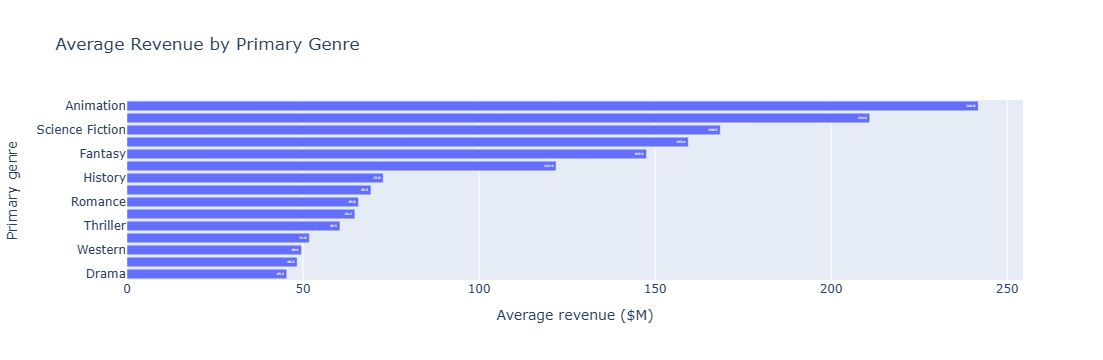

In [57]:
genre_chart_data = genre_summary.sort_values("avg_revenue_million").tail(15)

fig_genre = px.bar(
    genre_chart_data,
    x="avg_revenue_million",
    y="primary_genre",
    orientation="h",
    text_auto=".1f",
    title="Average Revenue by Primary Genre",
    labels={
        "avg_revenue_million": "Average revenue ($M)",
        "primary_genre": "Primary genre"
    }
)

fig_genre.show()

### budget vs revenue

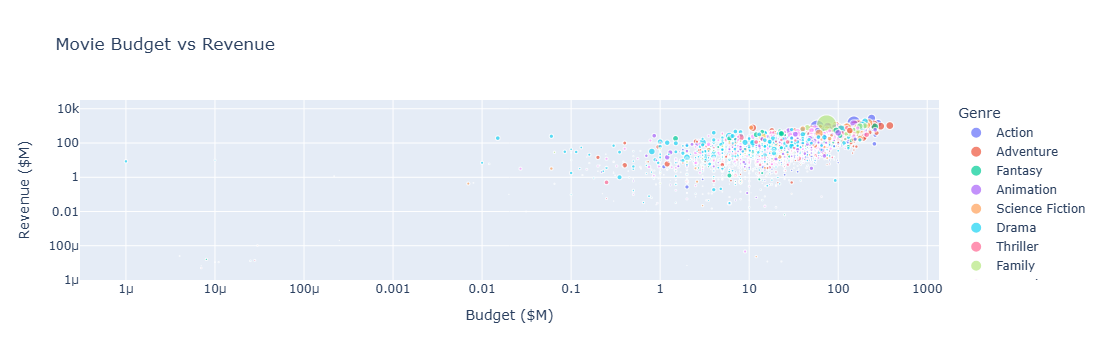

In [58]:
scatter_df = merged_df[
    (merged_df["budget_million"] > 0) &
    (merged_df["revenue_million"] > 0)
].copy()

fig_budget = px.scatter(
    scatter_df,
    x="budget_million",
    y="revenue_million",
    size="popularity",
    hover_name="title",
    color="primary_genre",
    log_x=True,
    log_y=True,
    title="Movie Budget vs Revenue",
    labels={
        "budget_million": "Budget ($M)",
        "revenue_million": "Revenue ($M)",
        "primary_genre": "Genre"
    }
)

fig_budget.show()

### revenue trend over time

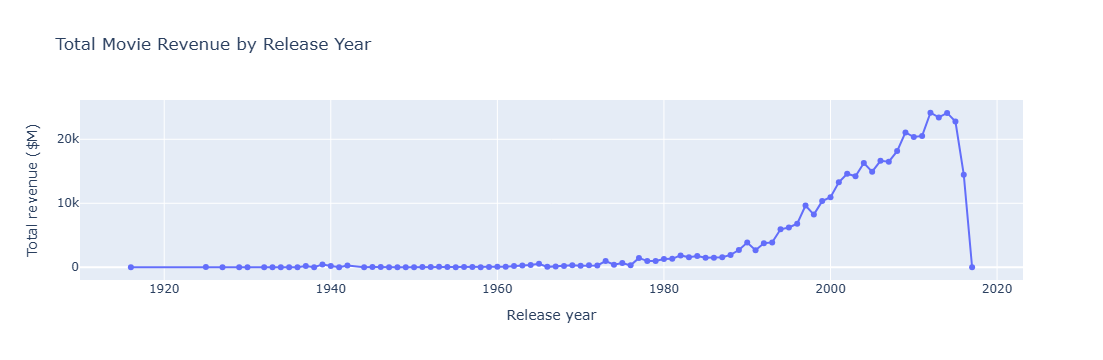

In [59]:
fig_year = px.line(
    yearly,
    x="release_year",
    y="total_revenue_million",
    markers=True,
    title="Total Movie Revenue by Release Year",
    labels={
        "release_year": "Release year",
        "total_revenue_million": "Total revenue ($M)"
    }
)

fig_year.show()

### top 10 movies by revenue

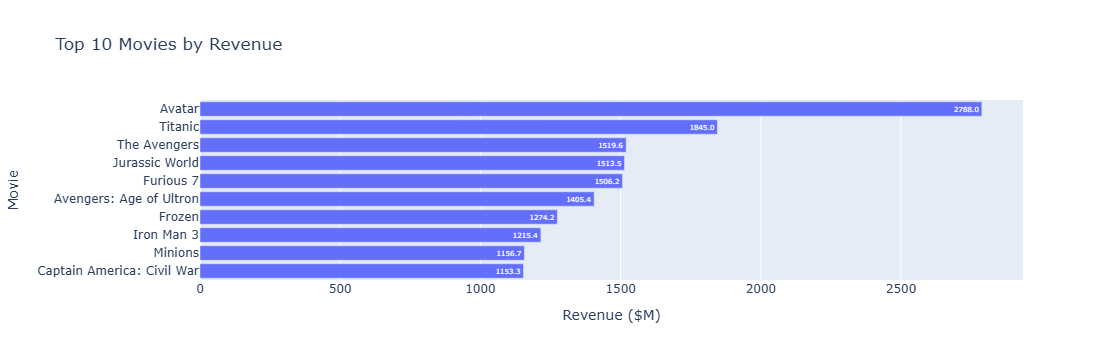

In [60]:
top10 = merged_df.nlargest(10, "revenue").sort_values("revenue")

fig_top10 = px.bar(
    top10,
    x="revenue_million",
    y="title",
    orientation="h",
    text_auto=".1f",
    title="Top 10 Movies by Revenue",
    labels={
        "revenue_million": "Revenue ($M)",
        "title": "Movie"
    }
)

fig_top10.show()

### Rating vs popularity

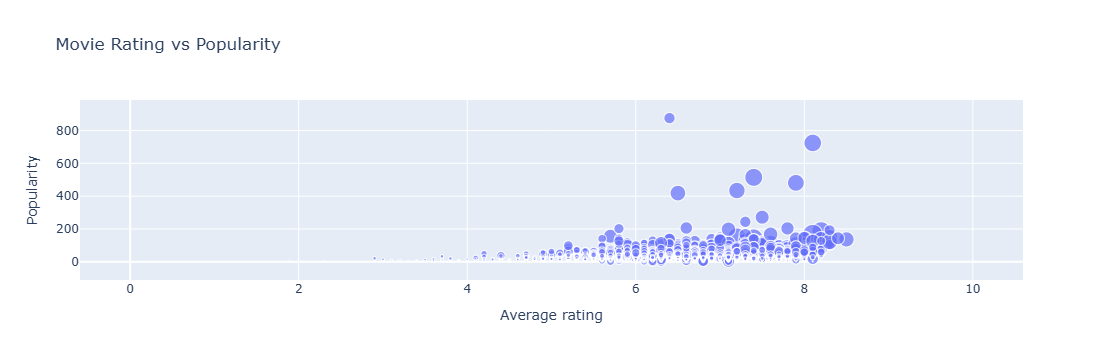

In [61]:
rating_df = merged_df[
    merged_df["vote_count"] > 0
].copy()

fig_rating = px.scatter(
    rating_df,
    x="vote_average",
    y="popularity",
    size="vote_count",
    hover_name="title",
    title="Movie Rating vs Popularity",
    labels={
        "vote_average": "Average rating",
        "popularity": "Popularity",
        "vote_count": "Number of votes"
    }
)

fig_rating.show()

### average rating by decade

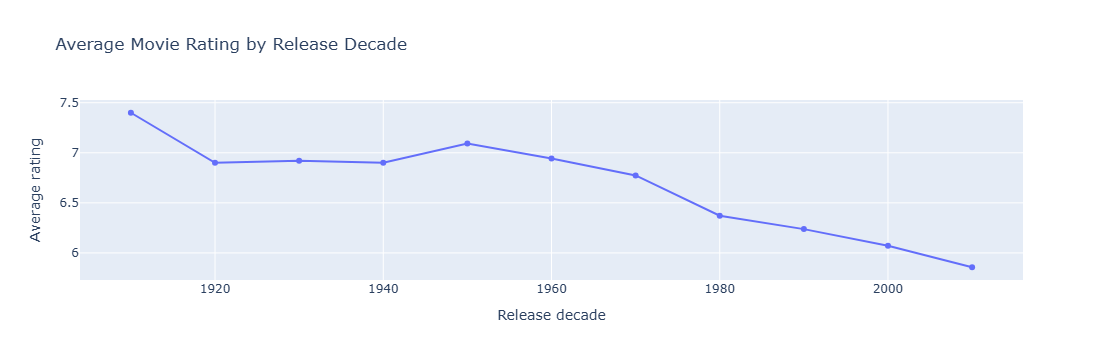

In [62]:
decade_summary = (
    merged_df.dropna(subset=["release_decade"])
    .groupby("release_decade", as_index=False)
    .agg(
        movies=("id", "count"),
        avg_rating=("vote_average", "mean"),
        avg_popularity=("popularity", "mean")
    )
)

fig_decade = px.line(
    decade_summary,
    x="release_decade",
    y="avg_rating",
    markers=True,
    title="Average Movie Rating by Release Decade",
    labels={
        "release_decade": "Release decade",
        "avg_rating": "Average rating"
    }
)

fig_decade.show()

### Interpreting the results

In [63]:
display(
    genre_summary.sort_values(
        "avg_revenue_million", ascending=False
    ).head(10)
)

,primary_genre,movies,avg_budget_million,avg_revenue_million,avg_rating,total_revenue_million
2,Animation,123,67.60,241.77,6.27,"29,737.17"
1,Adventure,339,65.60,210.96,6.31,"71,515.82"
15,Science Fiction,96,49.28,168.52,6.16,"16,178.15"
7,Family,56,42.69,159.42,5.65,"8,927.42"
8,Fantasy,117,52.54,147.56,6.17,"17,264.43"
0,Action,754,47.65,121.86,5.94,"91,883.49"
10,History,25,24.40,72.78,6.63,"1,819.40"
13,Mystery,41,22.37,69.29,6.14,"2,840.83"
14,Romance,106,20.54,65.75,6.19,"6,969.56"
18,War,24,36.55,64.72,6.60,"1,553.21"


### highest-revenue movies

In [64]:
display(top_revenue)

,title,primary_genre,budget_million,revenue_million,profit_million,vote_average,director
0,Avatar,Action,237.00,"2,787.97","2,550.97",7.20,James Cameron
25,Titanic,Drama,200.00,"1,845.03","1,645.03",7.50,James Cameron
16,The Avengers,Science Fiction,220.00,"1,519.56","1,299.56",7.40,Joss Whedon
28,Jurassic World,Action,150.00,"1,513.53","1,363.53",6.50,Colin Trevorrow
44,Furious 7,Action,190.00,"1,506.25","1,316.25",7.30,James Wan
7,Avengers: Age of Ultron,Action,280.00,"1,405.40","1,125.40",7.30,Joss Whedon
124,Frozen,Animation,150.00,"1,274.22","1,124.22",7.30,Chris Buck
31,Iron Man 3,Action,200.00,"1,215.44","1,015.44",6.80,Shane Black
546,Minions,Family,74.00,"1,156.73","1,082.73",6.40,Kyle Balda
26,Captain America: Civil War,Adventure,250.00,"1,153.30",903.30,7.10,Anthony Russo


### Highest-revenue directors with at least 3 movies

In [65]:
display(director_summary.head(10))

,director,movie_count,avg_revenue_million,avg_rating,total_revenue_million
2111,Steven Spielberg,27,338.79,6.97,"9,147.39"
1737,Peter Jackson,9,722.07,7.33,"6,498.64"
887,James Cameron,7,840.51,7.33,"5,883.57"
1483,Michael Bay,12,486.04,6.40,"5,832.52"
361,Christopher Nolan,8,528.44,7.80,"4,227.48"
321,Chris Columbus,11,338.69,6.59,"3,725.63"
1905,Robert Zemeckis,13,276.20,6.92,"3,590.62"
740,George Lucas,5,667.82,6.96,"3,339.11"
2171,Tim Burton,14,238.39,6.73,"3,337.42"
1852,Ridley Scott,16,199.35,6.69,"3,189.56"


### Final kpi's 

In [67]:
kpi_values = {
    "Movies": int(merged_df["id"].nunique()),
    "Revenue ($B)": float(merged_df["revenue"].sum() / 1_000_000_000),
    "Average Rating": float(merged_df["vote_average"].mean()),
    "Positive ROI Movies": int(merged_df["successful_movie"].sum())
}

kpi_values

{'Movies': 4803,
 'Revenue ($B)': 395.097847444,
 'Average Rating': 6.092171559442016,
 'Positive ROI Movies': 2438}

### Dashboard

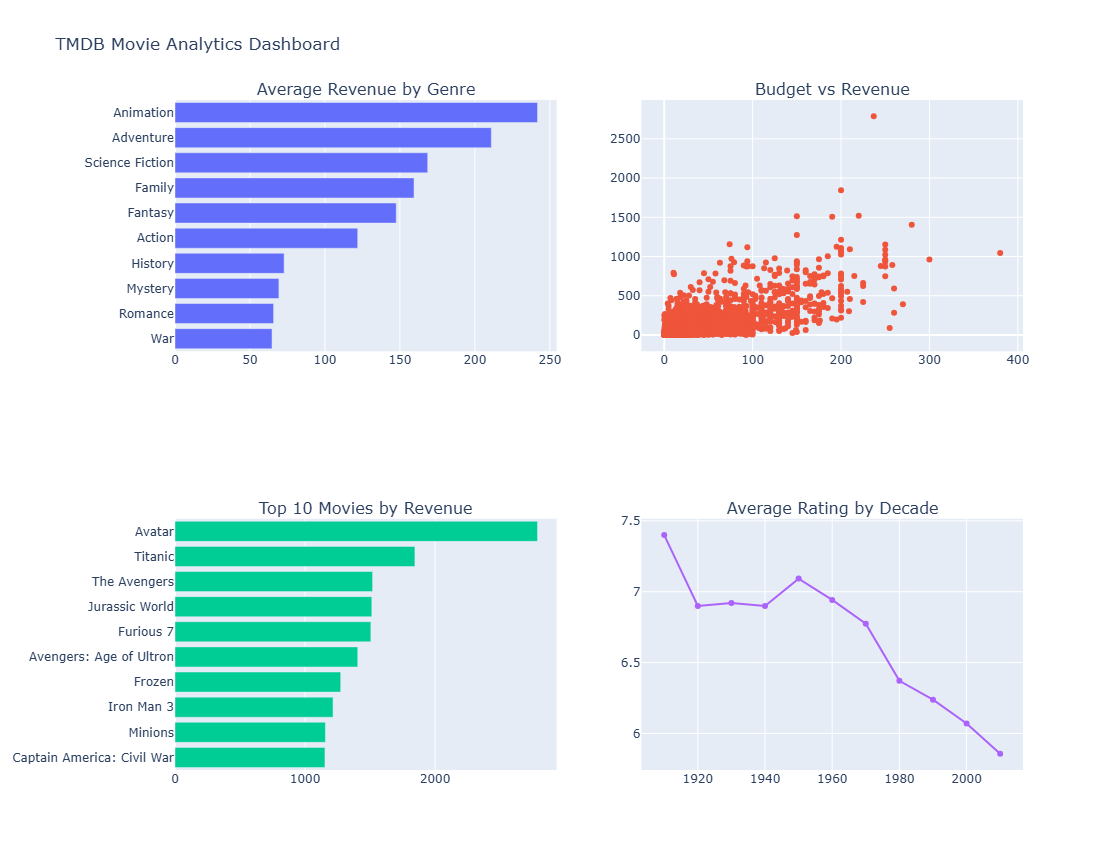

In [69]:
dashboard = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Average Revenue by Genre",
        "Budget vs Revenue",
        "Top 10 Movies by Revenue",
        "Average Rating by Decade"
    ),
    specs=[
        [{"type": "bar"}, {"type": "scatter"}],
        [{"type": "bar"}, {"type": "scatter"}]
    ]
)

genre_dash = genre_summary.sort_values(
    "avg_revenue_million"
).tail(10)

dashboard.add_trace(
    go.Bar(
        x=genre_dash["avg_revenue_million"],
        y=genre_dash["primary_genre"],
        orientation="h",
        name="Genre"
    ),
    row=1,
    col=1
)

dashboard.add_trace(
    go.Scatter(
        x=scatter_df["budget_million"],
        y=scatter_df["revenue_million"],
        mode="markers",
        text=scatter_df["title"],
        name="Movies"
    ),
    row=1,
    col=2
)

dashboard.add_trace(
    go.Bar(
        x=top10["revenue_million"],
        y=top10["title"],
        orientation="h",
        name="Top movies"
    ),
    row=2,
    col=1
)

dashboard.add_trace(
    go.Scatter(
        x=decade_summary["release_decade"],
        y=decade_summary["avg_rating"],
        mode="lines+markers",
        name="Rating"
    ),
    row=2,
    col=2
)

dashboard.update_layout(
    title="TMDB Movie Analytics Dashboard",
    height=850,
    showlegend=False
)

dashboard.show()

### Exporting the results

In [70]:
merged_df.to_csv(
    OUTPUT_PATH / "tmdb_merged_movie_data.csv",
    index=False
)

genre_summary.to_csv(
    OUTPUT_PATH / "genre_summary.csv",
    index=False
)

yearly.to_csv(
    OUTPUT_PATH / "yearly_summary.csv",
    index=False
)

director_summary.to_csv(
    OUTPUT_PATH / "director_summary.csv",
    index=False
)

quality_report.to_csv(
    OUTPUT_PATH / "quality_report.csv",
    index=False
)

dashboard.write_html(
    OUTPUT_PATH / "movie_dashboard.html",
    include_plotlyjs=True
)

[file.name for file in sorted(OUTPUT_PATH.iterdir())]

['director_summary.csv',
 'genre_summary.csv',
 'movie_dashboard.html',
 'quality_report.csv',
 'tmdb_merged_movie_data.csv',
 'yearly_summary.csv']